##### Using pretrained diffusion pipelines
in this document we will be evaluating the use of pre trained diffusion pipelines to generate multiview images of a particular target object which is the first stage of our 3d image generator

In [1]:
import torch
from diffusers import DiffusionPipeline

multi_view_diffusion_pipeline = DiffusionPipeline.from_pretrained(
    "dylanebert/multi-view-diffusion",
    custom_pipeline="dylanebert/multi-view-diffusion",
    torch_dtype=torch.float16, # uses torch backend underneath
    trust_remote_code=True,
).to("cuda")

/home/kaarl/miniconda3/envs/lgm-py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Keyword arguments {'trust_remote_code': True} are not expected by MVDreamPipeline and will be ignored.
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 14.44it/s]
Expected types for unet: (<class 'diffusers_modules.local.dylanebert--multi-view-diffusion.3916e5568b2ee54ea8a81ce4961609158b2c464d.pipeline.MultiViewUNetModel'>,), got <class 'diffusers_modules.local.mv_unet.MultiViewUNetModel'>.


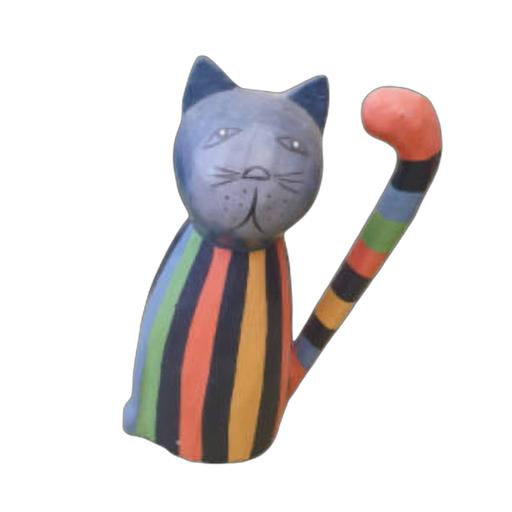

In [3]:
import requests
from io import BytesIO
from PIL import Image

image_url = "https://huggingface.co/datasets/dylanebert/3d-arena/resolve/main/inputs/images/a_cat_statue.jpg"
response = requests.get(image_url)
image = Image.open(BytesIO(response.content))
image

run the multiview image generation pipeline

100%|██████████| 30/30 [00:02<00:00, 11.79it/s]


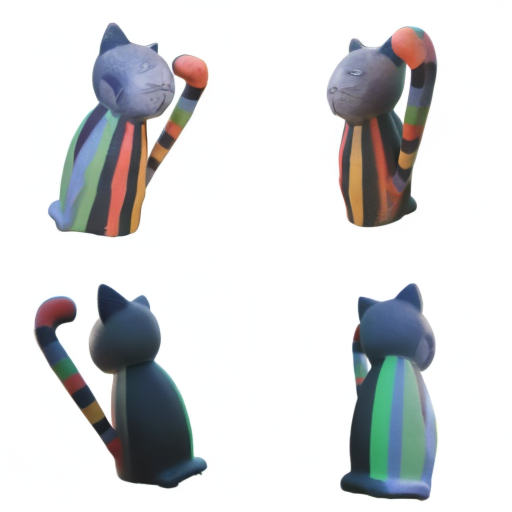

In [4]:
import numpy as np

def create_image_grid(images):
    images = [Image.fromarray((img * 255).astype("uint8")) for img in images]

    width, height = images[0].size
    grid_img = Image.new("RGB", (2 * width, 2 * height))

    grid_img.paste(images[0], (0, 0))
    grid_img.paste(images[1], (width, 0))
    grid_img.paste(images[2], (0, height))
    grid_img.paste(images[3], (width, height))

    return grid_img

image = np.array(image, dtype=np.float32) / 255.0
images = multi_view_diffusion_pipeline("", image, guidance_scale=5, num_inference_steps=30, elevation=0)

create_image_grid(images)

we can now see our image from multiple angles, the next question is: can we specify within the pipeline which angles and faces we would like it to generate as opposed to simply gnerating a rnadom set of angles, this might also be useful for positioning of the image for the ml 3d pipeline which takes the multi-dimensional image